# parameter recovery


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from matplotlib.ticker import FormatStrFormatter

outputFolderName = r"param_recovery_6_finding_correlations"
from scipy.io import loadmat, savemat

# read params

In [2]:
inputFolderNameParams = r"param_recovery_4_param_recovery"

if not os.path.exists(outputFolderName):
    os.makedirs(outputFolderName)

file_path = os.path.join(inputFolderNameParams, "alpha_comparison.csv")
df = pd.read_csv(file_path)


fit_alpha_plus = df["fit_alpha_plus"].to_numpy(dtype=float)
fit_alpha_minus = df["fit_alpha_minus"].to_numpy(dtype=float)
ptIDs = df["ptID"].to_numpy(dtype=str)

# read pt param recovery data

In [3]:
inputFolderName = r"\\155.100.91.44\d\Data\Nill\BART_param_recovery\context_modeling\param_recovery_3_simulated_fields"


if not os.path.exists(outputFolderName):
    os.makedirs(outputFolderName)


matFiles = [f for f in os.listdir(inputFolderName) if f.endswith(".mat")]
nPatients = len(matFiles)


# ( alpha_minus - alpha_plus ) / ( alpha_minus + alpha_plus )

> 0 : risk aversion
< 0 : risk seeking

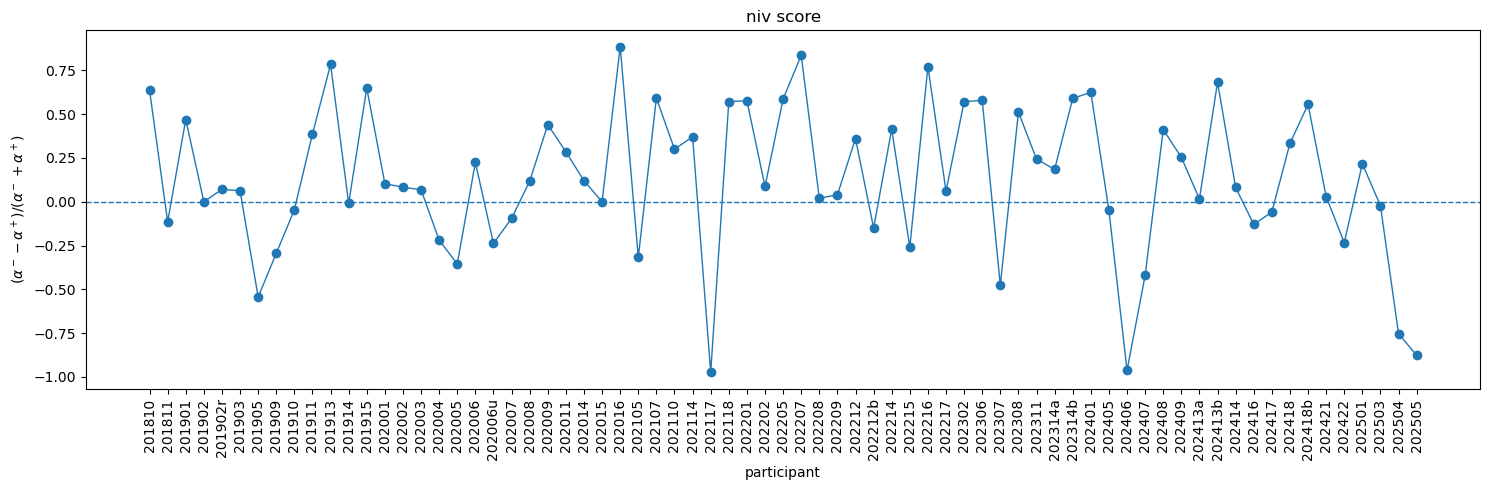

In [4]:
fit_alpha_plus = np.asarray(fit_alpha_plus, dtype=float)
fit_alpha_minus = np.asarray(fit_alpha_minus, dtype=float)

alpha_asymmetry = (fit_alpha_minus - fit_alpha_plus) / (fit_alpha_minus + fit_alpha_plus)

# plot
plt.figure(figsize=(15, 5))
plt.plot(alpha_asymmetry, 'o-', linewidth=1)
plt.axhline(0, linestyle='--', linewidth=1)

plt.xlabel('participant')
plt.ylabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
plt.title('niv score')
plt.xticks(np.arange(len(alpha_asymmetry)))

plt.xticks(np.arange(len(alpha_asymmetry)), ptIDs, rotation=90)

plt.tight_layout()

save_path = os.path.join(outputFolderName, "alpha_asymmetry_by_participant.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# all accuracy

In [7]:
all_accuracy = []
all_ptIDs = []

for pt in range(nPatients):
# for pt in range(1):

    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    non_control_idx = ~is_control

    accuracy = np.sum(result[non_control_idx] == "banked") / np.sum(non_control_idx)
    all_accuracy.append(accuracy)
    all_ptIDs.append(ptID)


processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

# all accuracy vs. niv score

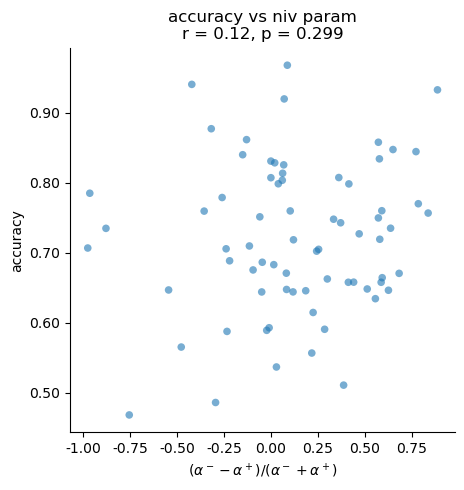

In [22]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_accuracy = np.asarray(all_accuracy, dtype=float)

valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_accuracy)
x = alpha_asymmetry[valid]
y = all_accuracy[valid]

if len(x) < 2:
    print("Not enough valid points")
else:
    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    # square plot
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(x, y, alpha=0.6, edgecolors='none', s=30, label="participants")

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel("accuracy")
    ax.set_title(f"accuracy vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.tight_layout()
    plt.show()

# accuracy yellow and orange

In [23]:
all_accuracy = []
all_ptIDs = []

for pt in range(nPatients):
# for pt in range(1):

    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    trial_type = np.asarray(TDdataParamRecovery.trial_type).astype(int).squeeze()[0:nTrials-1]

    non_control_idx = ~is_control
    valid_trialtype_idx = np.isin(trial_type, [1, 2])   # yellow and orange
    valid_idx = non_control_idx & valid_trialtype_idx

    if np.sum(valid_idx) > 0:
        accuracy = np.sum(result[valid_idx] == "banked") / np.sum(valid_idx)
    else:
        accuracy = np.nan

    all_accuracy.append(accuracy)
    all_ptIDs.append(ptID)

processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

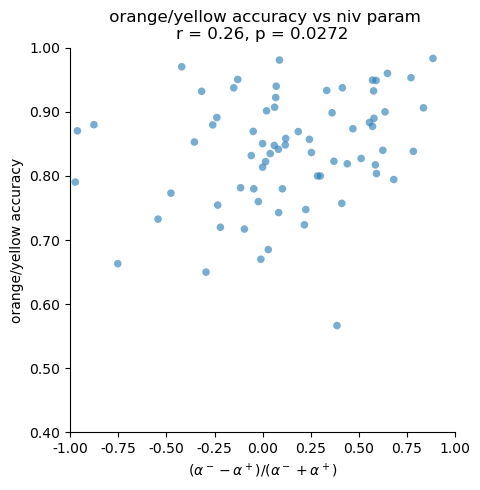

In [29]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_accuracy = np.asarray(all_accuracy, dtype=float)

valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_accuracy)
x = alpha_asymmetry[valid]
y = all_accuracy[valid]

if len(x) < 2:
    print("Not enough valid points")
else:
    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    # square plot
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(x, y, alpha=0.6, edgecolors='none', s=30, label="participants")

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel("orange/yellow accuracy")
    ax.set_title(f" orange/yellow accuracy vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_xlim(-1, 1)
    ax.set_ylim(0.4, 1)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.tight_layout()
    plt.show()

# separate yellow, orange, red accuracy

In [30]:
all_n_yellow = []
all_n_orange = []
all_n_red = []

all_accuracy_yellow = []
all_accuracy_orange = []
all_accuracy_red = []
all_ptIDs = []

for pt in range(nPatients):
    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    trial_type = np.asarray(TDdataParamRecovery.trial_type).astype(int).squeeze()[0:nTrials-1]

    non_control_idx = ~is_control

    yellow_idx = non_control_idx & (trial_type == 1)
    orange_idx = non_control_idx & (trial_type == 2)
    red_idx = non_control_idx & (trial_type == 3)

    n_yellow = np.sum(yellow_idx)
    n_orange = np.sum(orange_idx)
    n_red = np.sum(red_idx)

    accuracy_yellow = np.sum(result[yellow_idx] == "banked") / n_yellow if n_yellow > 0 else np.nan
    accuracy_orange = np.sum(result[orange_idx] == "banked") / n_orange if n_orange > 0 else np.nan
    accuracy_red = np.sum(result[red_idx] == "banked") / n_red if n_red > 0 else np.nan

    all_accuracy_yellow.append(accuracy_yellow)
    all_accuracy_orange.append(accuracy_orange)
    all_accuracy_red.append(accuracy_red)

    all_n_yellow.append(n_yellow)
    all_n_orange.append(n_orange)
    all_n_red.append(n_red)

    all_ptIDs.append(ptID)

df_accuracy = pd.DataFrame({
    "ptID": all_ptIDs,
    "accuracy_yellow": all_accuracy_yellow,
    "n_yellow": all_n_yellow,
    "accuracy_orange": all_accuracy_orange,
    "n_orange": all_n_orange,
    "accuracy_red": all_accuracy_red,
    "n_red": all_n_red,
})

print(df_accuracy)

processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

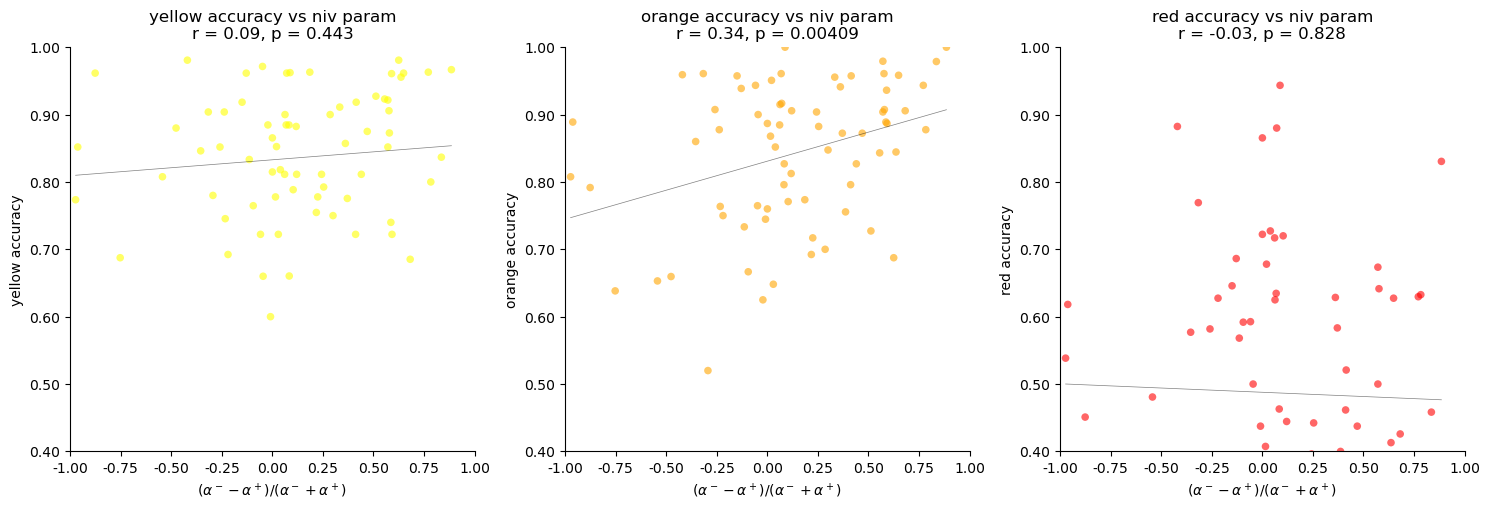

In [35]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_accuracy_yellow = np.asarray(all_accuracy_yellow, dtype=float)
all_accuracy_orange = np.asarray(all_accuracy_orange, dtype=float)
all_accuracy_red = np.asarray(all_accuracy_red, dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

accuracy_data = [
    (all_accuracy_yellow, "yellow accuracy", "yellow"),
    (all_accuracy_orange, "orange accuracy", "orange"),
    (all_accuracy_red, "red accuracy", "red"),
]

for ax, (all_accuracy_curr, label, color) in zip(axes, accuracy_data):
    valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_accuracy_curr)
    x = alpha_asymmetry[valid]
    y = all_accuracy_curr[valid]

    if len(x) < 2:
        ax.text(0.5, 0.5, "Not enough valid points",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{label} vs niv param")
        ax.set_box_aspect(1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        continue

    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    ax.scatter(x, y, color=color, alpha=0.6, edgecolors='none', s=30)
    ax.plot(np.sort(x), m * np.sort(x) + b, color='black', linewidth=0.5, alpha=0.5)

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_xlim(-1, 1)
    ax.set_ylim(0.4, 1)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# inflation times

In [36]:
all_mean_inflate_time = []
all_ptIDs = []

for pt in range(nPatients):
# for pt in range(1):

    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    inflate_time = np.asarray(TDdataParamRecovery.inflate_time, dtype=float).squeeze()[0:nTrials-1]

    valid_idx = (~is_control) & (result == "banked")

    if np.sum(valid_idx) > 0:
        mean_inflate_time = np.nanmean(inflate_time[valid_idx])
    else:
        mean_inflate_time = np.nan

    all_mean_inflate_time.append(mean_inflate_time)
    all_ptIDs.append(ptID)

processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

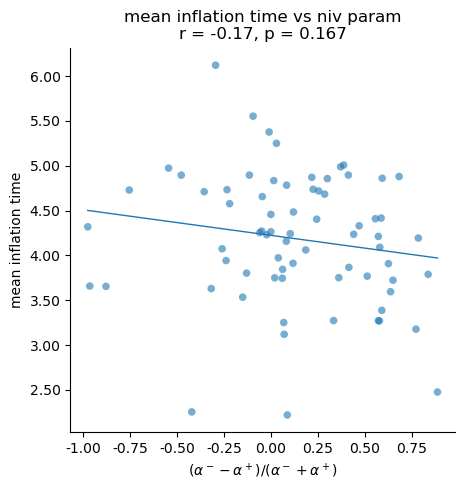

In [ ]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_mean_inflate_time = np.asarray(all_mean_inflate_time, dtype=float)

valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_mean_inflate_time)
x = alpha_asymmetry[valid]
y = all_mean_inflate_time[valid]

if len(x) < 2:
    print("Not enough valid points")
else:
    m, b = np.polyfit(x, y, 1)
    r, p = pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(x, y, alpha=0.6, edgecolors='none', s=30)
    ax.plot(np.sort(x), m*np.sort(x) + b, linewidth=1)

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel("mean inflation time (s)")
    ax.set_title(f"mean inflation time vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.tight_layout()
    plt.show()

# orange yellow inflation time

In [38]:
all_mean_inflate_time = []
all_ptIDs = []

for pt in range(nPatients):
# for pt in range(1):

    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    trial_type = np.asarray(TDdataParamRecovery.trial_type).astype(int).squeeze()[0:nTrials-1]
    inflate_time = np.asarray(TDdataParamRecovery.inflate_time, dtype=float).squeeze()[0:nTrials-1]

    non_control_idx = ~is_control
    valid_trialtype_idx = np.isin(trial_type, [1, 2])   # yellow and orange
    banked_idx = (result == "banked")

    valid_idx = non_control_idx & valid_trialtype_idx & banked_idx

    if np.sum(valid_idx) > 0:
        mean_inflate_time = np.nanmean(inflate_time[valid_idx])
    else:
        mean_inflate_time = np.nan

    all_mean_inflate_time.append(mean_inflate_time)
    all_ptIDs.append(ptID)

processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

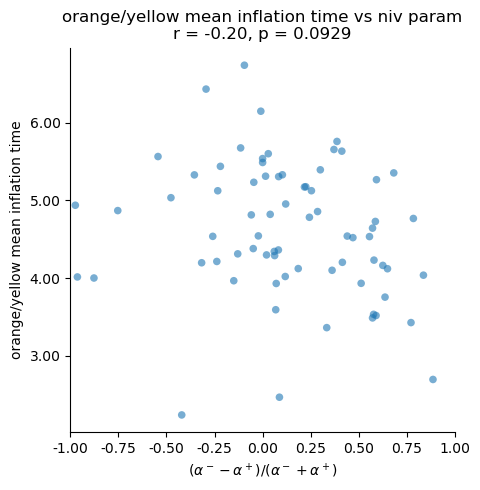

In [39]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_mean_inflate_time = np.asarray(all_mean_inflate_time, dtype=float)

valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_mean_inflate_time)
x = alpha_asymmetry[valid]
y = all_mean_inflate_time[valid]

if len(x) < 2:
    print("Not enough valid points")
else:
    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    # square plot
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(x, y, alpha=0.6, edgecolors='none', s=30, label="participants")

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel("orange/yellow mean inflation time")
    ax.set_title(f"orange/yellow mean inflation time vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_xlim(-1, 1)
    # optionally set y-limits manually if you want:
    # ax.set_ylim(0, 5)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    plt.tight_layout()
    plt.show()

# separate yellow, orange, red IT

In [40]:
all_n_yellow = []
all_n_orange = []
all_n_red = []

all_inflation_time_yellow = []
all_inflation_time_orange = []
all_inflation_time_red = []
all_ptIDs = []

for pt in range(nPatients):
    fileName = matFiles[pt]

    ptID = os.path.splitext(fileName)[0]
    ptID = ptID.replace("_TDdataParamRecovery", "")

    print(f"processing pt {pt+1}/{nPatients}: {ptID}")

    matFile = os.path.join(inputFolderName, fileName)
    mat = loadmat(matFile, struct_as_record=False, squeeze_me=True)

    TDdataParamRecovery = mat["TDdataParamRecovery"]
    nTrials = TDdataParamRecovery.nTrials

    result = np.asarray(TDdataParamRecovery.result).astype(str).squeeze()[0:nTrials-1]
    is_control = np.asarray(TDdataParamRecovery.is_control).astype(bool).squeeze()[0:nTrials-1]
    trial_type = np.asarray(TDdataParamRecovery.trial_type).astype(int).squeeze()[0:nTrials-1]
    inflate_time = np.asarray(TDdataParamRecovery.inflate_time, dtype=float).squeeze()[0:nTrials-1]

    non_control_idx = ~is_control
    banked_idx = (result == "banked")

    yellow_idx = non_control_idx & banked_idx & (trial_type == 1)
    orange_idx = non_control_idx & banked_idx & (trial_type == 2)
    red_idx = non_control_idx & banked_idx & (trial_type == 3)

    n_yellow = np.sum(yellow_idx)
    n_orange = np.sum(orange_idx)
    n_red = np.sum(red_idx)

    inflation_time_yellow = np.nanmean(inflate_time[yellow_idx]) if n_yellow > 0 else np.nan
    inflation_time_orange = np.nanmean(inflate_time[orange_idx]) if n_orange > 0 else np.nan
    inflation_time_red = np.nanmean(inflate_time[red_idx]) if n_red > 0 else np.nan

    all_inflation_time_yellow.append(inflation_time_yellow)
    all_inflation_time_orange.append(inflation_time_orange)
    all_inflation_time_red.append(inflation_time_red)

    all_n_yellow.append(n_yellow)
    all_n_orange.append(n_orange)
    all_n_red.append(n_red)

    all_ptIDs.append(ptID)

df_inflation_time = pd.DataFrame({
    "ptID": all_ptIDs,
    "inflation_time_yellow": all_inflation_time_yellow,
    "n_yellow": all_n_yellow,
    "inflation_time_orange": all_inflation_time_orange,
    "n_orange": all_n_orange,
    "inflation_time_red": all_inflation_time_red,
    "n_red": all_n_red,
})

print(df_inflation_time)

processing pt 1/71: 201810
processing pt 2/71: 201811
processing pt 3/71: 201901
processing pt 4/71: 201902r
processing pt 5/71: 201902
processing pt 6/71: 201903
processing pt 7/71: 201905
processing pt 8/71: 201909
processing pt 9/71: 201910
processing pt 10/71: 201911
processing pt 11/71: 201913
processing pt 12/71: 201914
processing pt 13/71: 201915
processing pt 14/71: 202001
processing pt 15/71: 202002
processing pt 16/71: 202003
processing pt 17/71: 202004
processing pt 18/71: 202005
processing pt 19/71: 202006u
processing pt 20/71: 202006
processing pt 21/71: 202007
processing pt 22/71: 202008
processing pt 23/71: 202009
processing pt 24/71: 202011
processing pt 25/71: 202014
processing pt 26/71: 202015
processing pt 27/71: 202016
processing pt 28/71: 202105
processing pt 29/71: 202107
processing pt 30/71: 202110
processing pt 31/71: 202114
processing pt 32/71: 202117
processing pt 33/71: 202118
processing pt 34/71: 202201
processing pt 35/71: 202202
processing pt 36/71: 202205

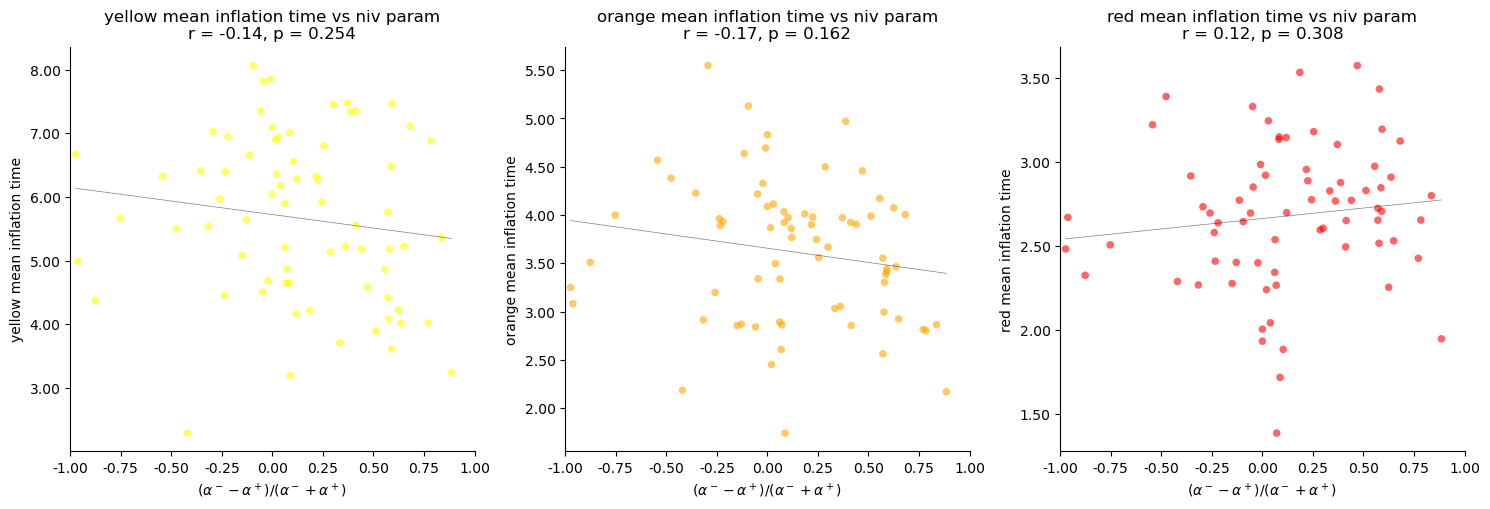

In [44]:
alpha_asymmetry = np.asarray(alpha_asymmetry, dtype=float)
all_inflation_time_yellow = np.asarray(all_inflation_time_yellow, dtype=float)
all_inflation_time_orange = np.asarray(all_inflation_time_orange, dtype=float)
all_inflation_time_red = np.asarray(all_inflation_time_red, dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

inflation_data = [
    (all_inflation_time_yellow, "yellow mean inflation time", "yellow"),
    (all_inflation_time_orange, "orange mean inflation time", "orange"),
    (all_inflation_time_red, "red mean inflation time", "red"),
]

for ax, (all_inflation_time_curr, label, color) in zip(axes, inflation_data):
    valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(all_inflation_time_curr)
    x = alpha_asymmetry[valid]
    y = all_inflation_time_curr[valid]

    if len(x) < 2:
        ax.text(0.5, 0.5, "Not enough valid points",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{label} vs niv param")
        ax.set_box_aspect(1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        continue

    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    ax.scatter(x, y, color=color, alpha=0.6, edgecolors='none', s=30)
    ax.plot(np.sort(x), m * np.sort(x) + b, color='black', linewidth=0.5, alpha=0.5)

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_xlim(-1, 1)
    # set this only if you want fixed y-range:
    # ax.set_ylim(0, 5)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# difference between mean IT for each pair:

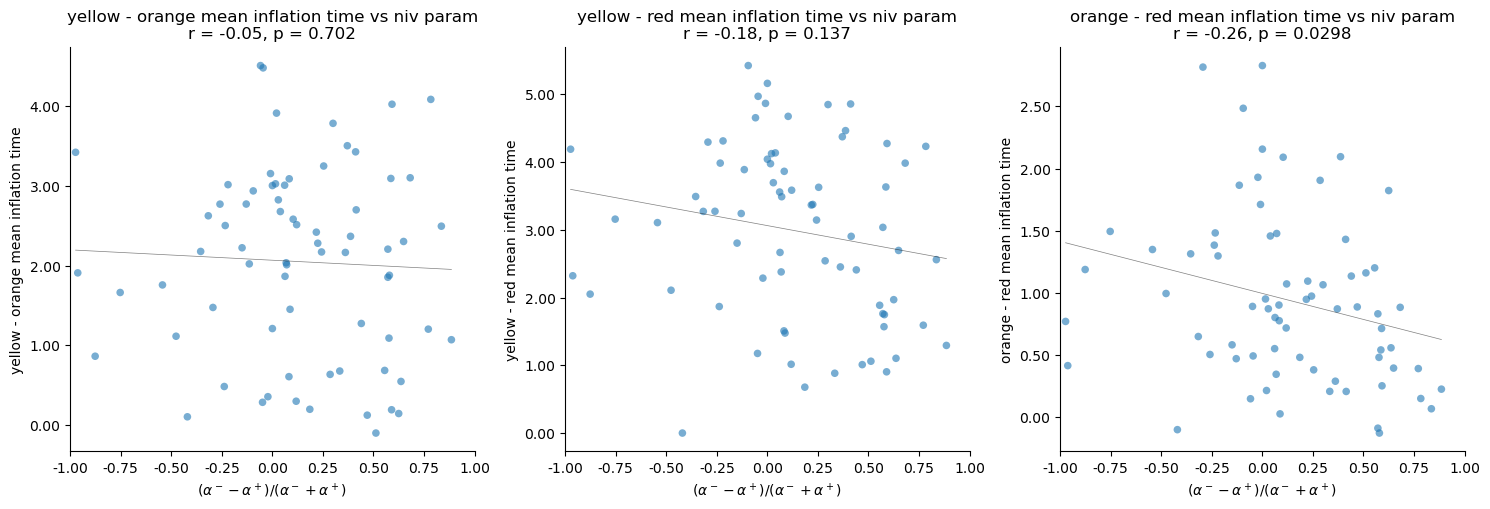

In [45]:
IT_yellow_orange_diff = all_inflation_time_yellow - all_inflation_time_orange
IT_yellow_red_diff = all_inflation_time_yellow - all_inflation_time_red
IT_orange_red_diff = all_inflation_time_orange - all_inflation_time_red

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

diff_data = [
    (IT_yellow_orange_diff, "yellow - orange mean inflation time"),
    (IT_yellow_red_diff, "yellow - red mean inflation time"),
    (IT_orange_red_diff, "orange - red mean inflation time"),
]

for ax, (curr_diff, label) in zip(axes, diff_data):
    valid = ~np.isnan(alpha_asymmetry) & ~np.isnan(curr_diff)
    x = alpha_asymmetry[valid]
    y = curr_diff[valid]

    if len(x) < 2:
        ax.text(0.5, 0.5, "Not enough valid points",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{label} vs niv param")
        ax.set_box_aspect(1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        continue

    # fit line
    m, b = np.polyfit(x, y, 1)

    # Pearson correlation
    r, p = pearsonr(x, y)

    # scatter + fit line
    ax.scatter(x, y, alpha=0.6, edgecolors='none', s=30)
    ax.plot(np.sort(x), m * np.sort(x) + b, color='black', linewidth=0.5, alpha=0.5)

    ax.set_xlabel(r'$(\alpha^- - \alpha^+)/(\alpha^- + \alpha^+)$')
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs niv param\nr = {r:.2f}, p = {p:.3g}")

    ax.set_xlim(-1, 1)
    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# DEBUG

In [6]:
fields = [f for f in dir(TDdataParamRecovery) if not f.startswith('_')]
print(fields)

['RPE', 'Reward', 'a', 'bestAlphaNeg', 'bestAlphaPos', 'bestAnIdx', 'bestApIdx', 'bestFitScore', 'bestInverseTemperature', 'bestLogLik', 'expectedReward', 'fitScoreRSTD', 'inflate_time', 'inverseTemperatureRSTD', 'is_control', 'logLikRSTD', 'logPriorAlphaNeg', 'logPriorAlphaPos', 'nTrials', 'points', 'pointsMinusReward', 'result', 'resultSimulated', 'rewardSimulated', 'scoreVec', 'trialTypes', 'trial_type']
